# Deep Learning
## Lab Assignment 3 - K-Nearest Neighbour Algorithm
Name: Ruta Lole

Roll no.: 61

PRN: 12310305

Class: TY CSAI-A

Batch: 3

## Title:
Write a program to implement k-Nearest Neighbour algorithm to classify the iris data set. Print both correct and wrong predictions. Python ML library classes can be used for this problem

## Load Iris Dataset & Libraries

In [2]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn kagglehub tensorflow seaborn


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())
print("\nTarget names:")
display(iris.target_names)

Features (X) head:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target (y) head:


0    0
1    0
2    0
3    0
4    0
dtype: int64


Target names:


array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Train-Test Split

In [4]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 120 samples
Testing set size: 30 samples


## Initialize and train the K-Nearest Neighbour classifier

In [5]:
# Initialize the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


## Make Predictions on Test Set

In [6]:
import pandas as pd

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Prepare lists to store correct and wrong predictions
correct_predictions = []
wrong_predictions = []

# Iterate through test samples to categorize predictions
for i in range(len(y_test)):
    # Get the features for the current test sample
    current_features = X_test.iloc[i]
    # Get the true label for the current test sample
    true_label_id = y_test.iloc[i]
    # Get the predicted label for the current test sample
    predicted_label_id = y_pred[i]

    # Map label IDs to names for better readability
    true_label_name = iris.target_names[true_label_id]
    predicted_label_name = iris.target_names[predicted_label_id]

    # Create a dictionary for the current prediction detail
    prediction_detail = {
        'Original Index': X_test.index[i],
        'Sepal Length (cm)': current_features['sepal length (cm)'],
        'Sepal Width (cm)': current_features['sepal width (cm)'],
        'Petal Length (cm)': current_features['petal length (cm)'],
        'Petal Width (cm)': current_features['petal width (cm)'],
        'True Label': true_label_name,
        'Predicted Label': predicted_label_name
    }

    if true_label_id == predicted_label_id:
        correct_predictions.append(prediction_detail)
    else:
        wrong_predictions.append(prediction_detail)


print("\n--- Correct Predictions Table ---")
if correct_predictions:
    df_correct = pd.DataFrame(correct_predictions)
    display(df_correct)
else:
    print("No correct predictions to display in table format.")

print("\n--- Wrong Predictions Table ---")
if wrong_predictions:
    df_wrong = pd.DataFrame(wrong_predictions)
    display(df_wrong)
else:
    print("No wrong predictions to display in table format.")


--- Correct Predictions Table ---


,Original Index,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),True Label,Predicted Label
0,38,4.4,3.0,1.3,0.2,setosa,setosa
1,127,6.1,3.0,4.9,1.8,virginica,virginica
2,57,4.9,2.4,3.3,1.0,versicolor,versicolor
3,93,5.0,2.3,3.3,1.0,versicolor,versicolor
4,42,4.4,3.2,1.3,0.2,setosa,setosa
5,56,6.3,3.3,4.7,1.6,versicolor,versicolor
6,22,4.6,3.6,1.0,0.2,setosa,setosa
7,20,5.4,3.4,1.7,0.2,setosa,setosa
8,147,6.5,3.0,5.2,2.0,virginica,virginica
9,84,5.4,3.0,4.5,1.5,versicolor,versicolor



--- Wrong Predictions Table ---
No wrong predictions to display in table format.


## Evaluate the classifier

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

Accuracy of the model: 100.00%


## Visualization

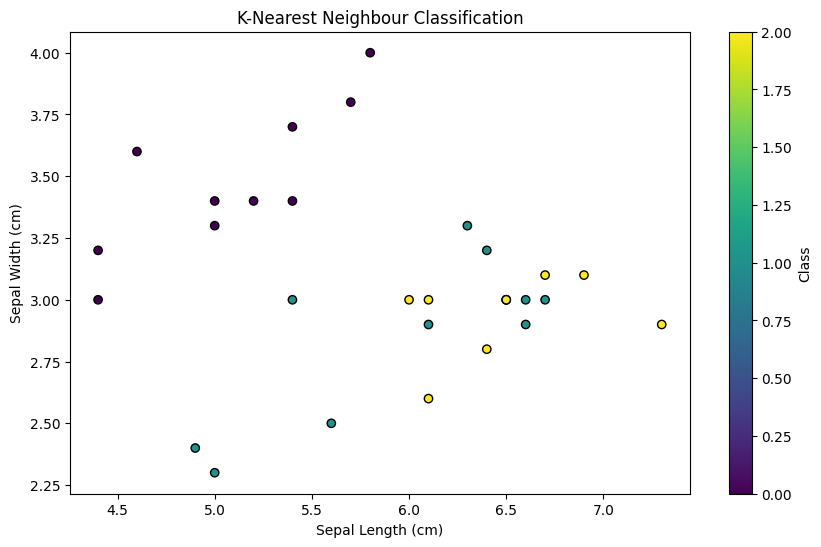

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(X_test['sepal length (cm)'], X_test['sepal width (cm)'], c=y_pred, cmap='viridis', edgecolor='k')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('K-Nearest Neighbour Classification')
plt.colorbar(label='Class')
plt.show()